<a href="https://colab.research.google.com/github/Brayanlira98/Telecom_X_parte_2/blob/main/Telecom_X_parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Extracción del Archivo Tratado

In [2]:
import pandas as pd
datos=pd.read_csv("/content/Datos_tratados.csv")
datos

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.60,593.30,2.156712
1,0003-MKNFE,No,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,1.969315
2,0004-TLHLJ,Yes,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.429589
3,0011-IGKFF,Yes,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.221918
4,0013-EXCHZ,Yes,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,2.758356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,0,0,13,1,0,DSL,...,0,1,0,0,One year,0,Mailed check,55.15,742.90,1.813151
7263,9992-RRAMN,Yes,Male,0,1,0,22,1,1,Fiber optic,...,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70,2.797808
7264,9992-UJOEL,No,Male,0,0,0,2,1,0,DSL,...,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.653699
7265,9993-LHIEB,No,Male,0,1,1,67,1,0,DSL,...,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,2.230685


#Eliminación de Columnas Irrelevantes

In [3]:
Datos_columnas_eliminadas=datos.drop('customerID',axis=1)
Datos_filtrados=Datos_columnas_eliminadas[Datos_columnas_eliminadas["Churn"].isin(["No", "Yes"])]
Datos_limpios=Datos_filtrados
Datos_limpios

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,No,Female,0,1,1,9,1,0,DSL,0,...,0,1,1,0,One year,1,Mailed check,65.60,593.30,2.156712
1,No,Male,0,0,0,9,1,1,DSL,0,...,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,1.969315
2,Yes,Male,0,0,0,4,1,0,Fiber optic,0,...,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.429589
3,Yes,Male,1,1,0,13,1,0,Fiber optic,0,...,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.221918
4,Yes,Female,1,1,0,3,1,0,Fiber optic,0,...,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,2.758356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,No,Female,0,0,0,13,1,0,DSL,1,...,0,1,0,0,One year,0,Mailed check,55.15,742.90,1.813151
7263,Yes,Male,0,1,0,22,1,1,Fiber optic,0,...,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70,2.797808
7264,No,Male,0,0,0,2,1,0,DSL,0,...,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.653699
7265,No,Male,0,1,1,67,1,0,DSL,1,...,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,2.230685


#Encoding

In [4]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

X=Datos_limpios.drop('Churn',axis=1)
Y=Datos_limpios['Churn']

columnas=X.columns
one_hot=make_column_transformer((OneHotEncoder(drop='if_binary'),['customer.gender','internet.InternetService','account.Contract','account.PaymentMethod']),remainder='passthrough',sparse_threshold=0,force_int_remainder_cols=False)
X=one_hot.fit_transform(X)
one_hot.get_feature_names_out(columnas)
E=pd.DataFrame(X,columns=one_hot.get_feature_names_out(columnas))
E

,onehotencoder__customer.gender_Male,onehotencoder__internet.InternetService_DSL,onehotencoder__internet.InternetService_Fiber optic,onehotencoder__internet.InternetService_No,onehotencoder__account.Contract_Month-to-month,onehotencoder__account.Contract_One year,onehotencoder__account.Contract_Two year,onehotencoder__account.PaymentMethod_Bank transfer (automatic),onehotencoder__account.PaymentMethod_Credit card (automatic),onehotencoder__account.PaymentMethod_Electronic check,...,remainder__internet.OnlineSecurity,remainder__internet.OnlineBackup,remainder__internet.DeviceProtection,remainder__internet.TechSupport,remainder__internet.StreamingTV,remainder__internet.StreamingMovies,remainder__account.PaperlessBilling,remainder__account.Charges.Monthly,remainder__account.Charges.Total,remainder__Cuentas_Diarias
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,65.60,593.30,2.156712
1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,59.90,542.40,1.969315
2,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,73.90,280.85,2.429589
3,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,1.0,1.0,1.0,98.00,1237.85,3.221918
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,83.90,267.40,2.758356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,55.15,742.90,1.813151
7039,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,85.10,1873.70,2.797808
7040,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,50.30,92.75,1.653699
7041,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,0.0,67.85,4627.65,2.230685


In [5]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
Y=label_encoder.fit_transform(Y)
Y

array([0, 0, 1, ..., 0, 0, 0])

#Verificación de la Proporción de Cancelación (Churn)

In [6]:
Datos_limpios['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


Se observa que la cantidad de 'No' es muy grande en compracion de 'YES'

#Balanceo de Clases

In [7]:
from imblearn.under_sampling import NearMiss
import numpy as np
undersample=NearMiss(version=3)
X_balanceada,Y_balanceada=undersample.fit_resample(X,Y)
z=pd.DataFrame(Y_balanceada)
z.value_counts(normalize=True)

,proportion
0,
0,0.5
1,0.5


#Normalización o Estandarización

In [8]:
from sklearn.preprocessing import MinMaxScaler
normalizacion=MinMaxScaler()
X_balanceada_y_normalizada=normalizacion.fit_transform(X_balanceada)
pd.DataFrame(X_balanceada_y_normalizada)

,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.998575,1.000000
1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.987494,0.998304,0.987494
2,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.981991,0.989568,0.981991
3,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.918459,0.916616,0.918459
4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.915458,0.917159,0.915458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3733,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.780390,0.232110,0.780390
3734,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.650825,0.089004,0.650825
3735,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.513757,0.005920,0.513757
3736,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.021511,0.007691,0.021511


#Análisis de Correlación

In [9]:
x_correlacion=pd.DataFrame(X_balanceada_y_normalizada,columns=E.columns)
x_correlacion
Y_correlacion= pd.Series(Y_balanceada, name="Churn")
Y_correlacion
df_corr = pd.concat([x_correlacion, Y_correlacion], axis=1)
df_corr
cor=df_corr.corr()
cor["Churn"].sort_values(ascending=False)

,Churn
Churn,1.000000
onehotencoder__account.Contract_Month-to-month,0.335760
onehotencoder__account.PaymentMethod_Electronic check,0.220506
onehotencoder__internet.InternetService_Fiber optic,0.146818
remainder__account.PaperlessBilling,0.121236
remainder__customer.SeniorCitizen,0.090827
remainder__account.Charges.Monthly,-0.007848
remainder__Cuentas_Diarias,-0.007848
remainder__phone.PhoneService,-0.010387
onehotencoder__customer.gender_Male,-0.014447


In [10]:
df_corr.columns

Index(['onehotencoder__customer.gender_Male',
       'onehotencoder__internet.InternetService_DSL',
       'onehotencoder__internet.InternetService_Fiber optic',
       'onehotencoder__internet.InternetService_No',
       'onehotencoder__account.Contract_Month-to-month',
       'onehotencoder__account.Contract_One year',
       'onehotencoder__account.Contract_Two year',
       'onehotencoder__account.PaymentMethod_Bank transfer (automatic)',
       'onehotencoder__account.PaymentMethod_Credit card (automatic)',
       'onehotencoder__account.PaymentMethod_Electronic check',
       'onehotencoder__account.PaymentMethod_Mailed check',
       'remainder__customer.SeniorCitizen', 'remainder__customer.Partner',
       'remainder__customer.Dependents', 'remainder__customer.tenure',
       'remainder__phone.PhoneService', 'remainder__phone.MultipleLines',
       'remainder__internet.OnlineSecurity',
       'remainder__internet.OnlineBackup',
       'remainder__internet.DeviceProtection',
   

#Análisis Dirigido

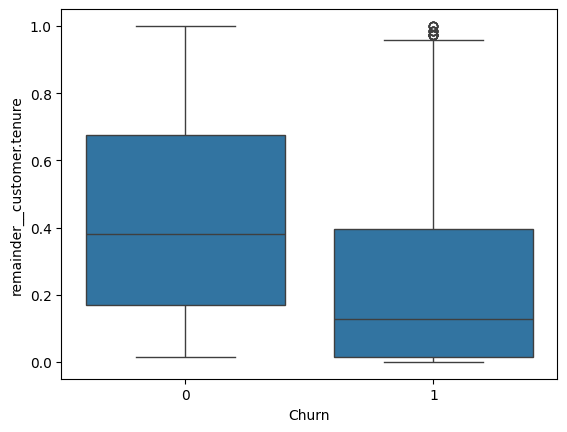

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Churn', y='remainder__customer.tenure', data=df_corr)

plt.show()

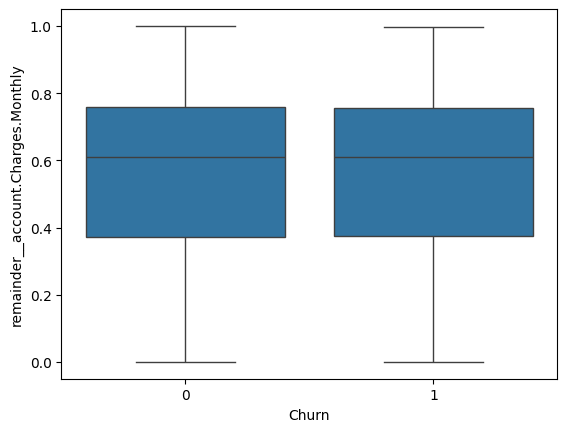

In [12]:
sns.boxplot(x='Churn', y='remainder__account.Charges.Monthly', data=df_corr)

plt.show()

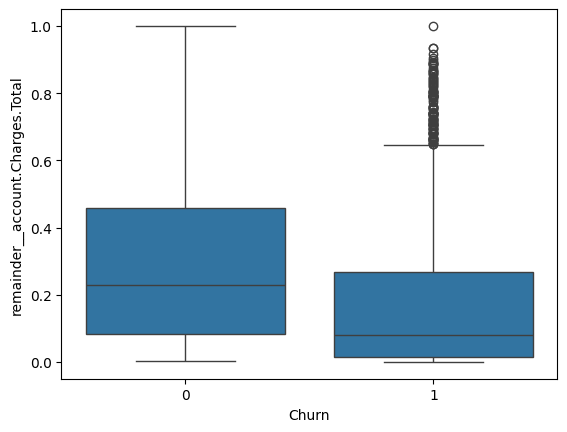

In [13]:
sns.boxplot(x='Churn', y='remainder__account.Charges.Total', data=df_corr)

plt.show()

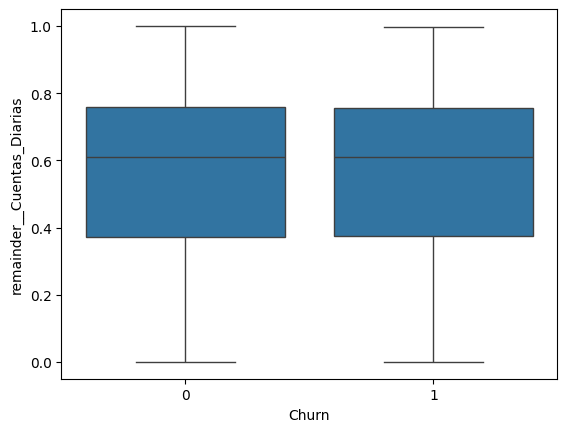

In [14]:
sns.boxplot(x='Churn', y='remainder__Cuentas_Diarias', data=df_corr)

plt.show()

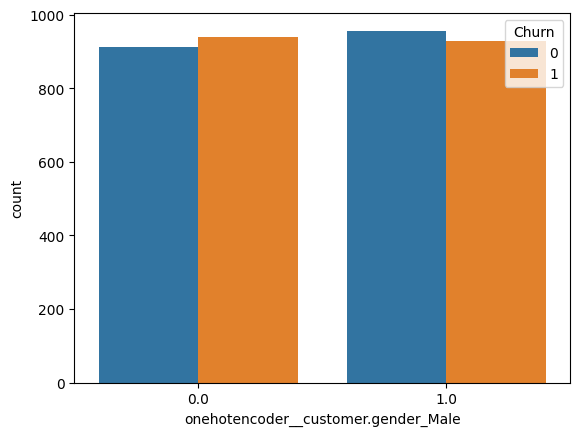

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='onehotencoder__customer.gender_Male', hue='Churn', data=df_corr)

plt.show()

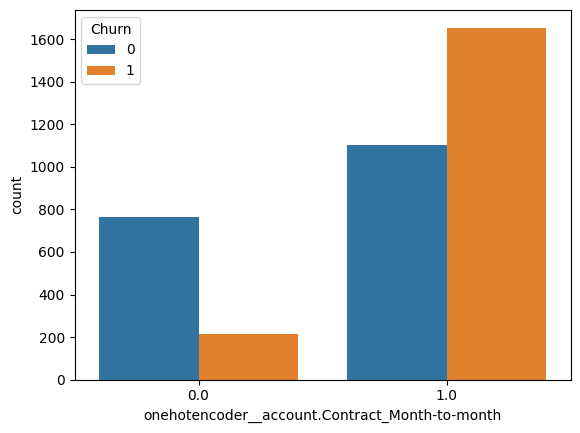

In [16]:
sns.countplot(x='onehotencoder__account.Contract_Month-to-month', hue='Churn', data=df_corr)

plt.show()

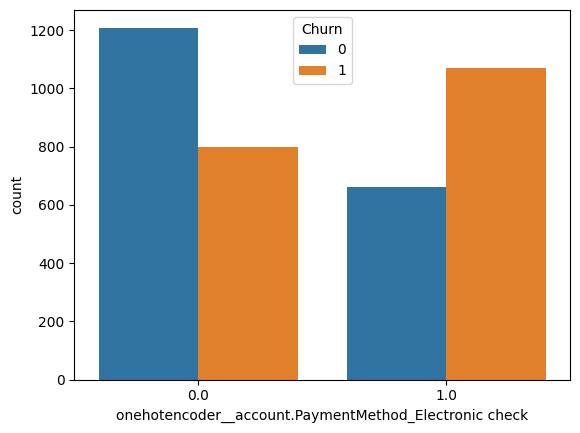

In [17]:
sns.countplot(x='onehotencoder__account.PaymentMethod_Electronic check', hue='Churn', data=df_corr)

plt.show()

#Separación de Datos

In [18]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(X_balanceada,Y_balanceada,stratify=Y_balanceada,random_state=5,test_size=0.3)

#Creación de Modelos

##Modelo Árbol de decisión

In [19]:
from sklearn.tree import DecisionTreeClassifier
modelo_arbol=DecisionTreeClassifier(max_depth=5,random_state=5)
modelo_arbol.fit(x_train,y_train)
modelo_arbol.score(x_test,y_test)

0.6916221033868093

In [25]:
modelo_arbol.fit(x_train,y_train)
modelo_arbol.score(x_train,y_train)

0.7198012232415902

##Modelo KNN

In [20]:
x_train_normalizado=normalizacion.fit_transform(x_train)


In [21]:
from sklearn.neighbors import KNeighborsClassifier
Knn=KNeighborsClassifier()
Knn.fit(x_train_normalizado,y_train)
x_test_normalizado=normalizacion.transform(x_test)
Knn.score(x_test_normalizado,y_test)

0.6631016042780749

In [26]:
Knn.fit(x_train_normalizado,y_train)
x_test_normalizado=normalizacion.transform(x_test)
Knn.score(x_train_normalizado,y_train)

0.7603211009174312

#Evaluación de los Modelos

##Modelo Árbol de decisión

Precisión = 0.7095516569200779
Exactitud = 0.6916221033868093
Recall = 0.6488413547237076
F1-score = 0.6778398510242085


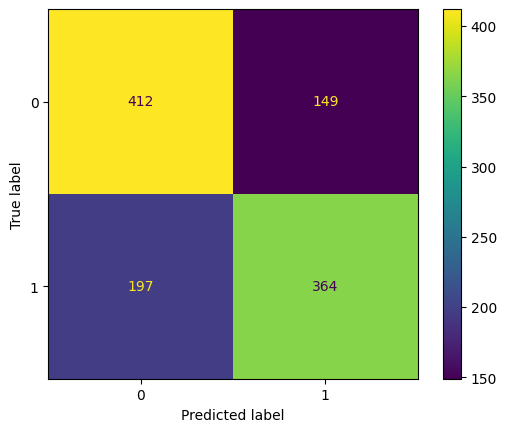

In [22]:
from sklearn.metrics import confusion_matrix
y_previsto=modelo_arbol.predict(x_test)
matriz_confusion=confusion_matrix(y_test,y_previsto)
from sklearn.metrics import ConfusionMatrixDisplay
visualizacion=ConfusionMatrixDisplay(matriz_confusion)
visualizacion.plot();

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
print(f'Precisión = {precision_score(y_test,y_previsto)}')
print(f'Exactitud = {accuracy_score(y_test,y_previsto)}')
print(f'Recall = {recall_score(y_test,y_previsto)}')
print(f'F1-score = {f1_score(y_test,y_previsto)}')

##Modelo KNN

Precisión = 0.6482982171799028
Exactitud = 0.6631016042780749
Recall = 0.7130124777183601
F1-score = 0.6791171477079796


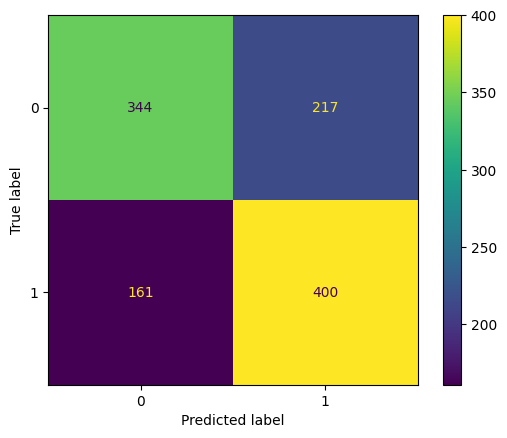

In [23]:
from sklearn.metrics import confusion_matrix
y_previsto2=Knn.predict(x_test_normalizado)
matriz_confusion2=confusion_matrix(y_test,y_previsto2)
from sklearn.metrics import ConfusionMatrixDisplay
visualizacion2=ConfusionMatrixDisplay(matriz_confusion2)
visualizacion2.plot();

print(f'Precisión = {precision_score(y_test,y_previsto2)}')
print(f'Exactitud = {accuracy_score(y_test,y_previsto2)}')
print(f'Recall = {recall_score(y_test,y_previsto2)}')
print(f'F1-score = {f1_score(y_test,y_previsto2)}')

Los modelos estudiados fueron evaluados utilizando las mismas métricas con el fin de compararlos y seleccionar el que presenta un mejor desempeño para aumentar la retención de clientes por parte de la empresa.

En cuanto a la precisión, el modelo de Árbol de decisión presenta un mejor resultado, lo que significa que cuando predice la clase positiva comete menos falsos positivos.

Para la exactitud, también el Árbol de decisión obtiene un mejor valor, lo que indica que, en general, clasifica correctamente un mayor número de observaciones.

En el caso del Recall, el modelo KNN presenta un valor más alto, lo que significa que detecta una mayor cantidad de casos positivos reales, aunque comete más falsos positivos.

Respecto al F1-score, ambos modelos presentan un rendimiento muy similar; sin embargo, KNN muestra un valor ligeramente superior.

Además, al analizar la matriz de confusión, se observa que el modelo de Árbol de decisión identifica correctamente una gran cantidad de casos positivos y presenta menos falsos positivos que KNN, lo que explica su mayor precisión. Por otro lado, el modelo KNN detecta un mayor número de casos positivos reales (mayor recall), aunque genera más falsos positivos, lo que reduce su precisión.

Tomando en consideración los puntos anteriores, y dado que el objetivo del modelo es identificar clientes con probabilidad de abandonar el servicio, la métrica más relevante es el Recall, ya que permite detectar la mayor cantidad posible de clientes que efectivamente se darán de baja. En este sentido, el modelo KNN presenta un mejor desempeño al obtener un Recall de 0.713 frente a 0.649 del modelo de Árbol de decisión, lo que indica que identifica un mayor número de clientes que realmente abandonarán la empresa.

Por esta razón, el modelo KNN resulta más adecuado para este problema de predicción de churn.

Al comparar el desempeño de los modelos en los conjuntos de entrenamiento y prueba, se observa que el modelo de Árbol de decisión obtiene una exactitud de 0.7198 en entrenamiento y 0.6916 en prueba, mostrando una diferencia pequeña entre ambos valores. Esto indica que el modelo presenta una buena capacidad de generalización y no muestra señales claras de overfitting o underfitting.

Por otro lado, el modelo KNN obtiene una exactitud de 0.7603 en entrenamiento y 0.6631 en prueba. La diferencia entre ambos valores es mayor, lo que sugiere que el modelo podría estar presentando cierto grado de overfitting, ya que su rendimiento disminuye al evaluarse en datos que no fueron utilizados durante el entrenamiento.

Aunque KNN tiene algo de overfitting, sigue siendo mejor para churn porque tiene mayor recall, lo cual detecta más clientes que abandonan.

#Análisis de la Importancia de las Variables

In [27]:
importancia = pd.Series(modelo_arbol.feature_importances_, index=E.columns)
importancia_ordenada = importancia.sort_values(ascending=False)
print(importancia_ordenada)

remainder__customer.tenure                                        0.512295
onehotencoder__account.Contract_Month-to-month                    0.243102
onehotencoder__account.PaymentMethod_Electronic check             0.068759
remainder__internet.OnlineSecurity                                0.035767
remainder__account.Charges.Total                                  0.030106
onehotencoder__internet.InternetService_DSL                       0.029138
remainder__account.Charges.Monthly                                0.025304
remainder__Cuentas_Diarias                                        0.020001
remainder__internet.StreamingTV                                   0.014930
onehotencoder__account.Contract_Two year                          0.013841
remainder__customer.SeniorCitizen                                 0.004050
onehotencoder__account.PaymentMethod_Credit card (automatic)      0.002131
onehotencoder__account.PaymentMethod_Bank transfer (automatic)    0.000576
onehotencoder__account.Pa

In [28]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    Knn,
    x_test_normalizado,
    y_test,
    n_repeats=10,
    random_state=5
)

importancia_knn = pd.Series(result.importances_mean, index=E.columns)

importancia_knn = importancia_knn.sort_values(ascending=False)

print(importancia_knn)

remainder__customer.tenure                                        0.037344
remainder__account.Charges.Total                                  0.020410
remainder__customer.SeniorCitizen                                 0.019251
onehotencoder__account.Contract_Month-to-month                    0.014439
onehotencoder__account.Contract_One year                          0.011765
remainder__internet.OnlineSecurity                                0.010250
remainder__internet.StreamingTV                                   0.009982
remainder__customer.Partner                                       0.008289
remainder__account.PaperlessBilling                               0.007576
remainder__phone.MultipleLines                                    0.006774
onehotencoder__internet.InternetService_DSL                       0.006328
onehotencoder__internet.InternetService_Fiber optic               0.006239
remainder__Cuentas_Diarias                                        0.005704
remainder__account.Charge

Para identificar las variables más relevantes en la predicción de la cancelación de clientes (Churn), se analizó la importancia de variables utilizando dos enfoques: la importancia de variables del modelo de Árbol de decisión y el método de Permutation Importance aplicado al modelo KNN. Este análisis permite determinar qué características de los clientes influyen en mayor medida en la probabilidad de abandono del servicio.

En el caso del modelo de Árbol de decisión, la variable con mayor importancia fue customer.tenure, con un valor de aproximadamente 0.51, lo que indica que el tiempo que un cliente ha permanecido en la empresa es el factor más influyente en la predicción de cancelación. Esto sugiere que los clientes con menor antigüedad presentan una mayor probabilidad de abandonar el servicio. La segunda variable más relevante fue Contract_Month-to-month, con una importancia cercana a 0.24, lo que indica que los clientes con contratos mensuales tienden a cancelar con mayor frecuencia, posiblemente debido a la mayor flexibilidad que ofrece este tipo de contrato. También destacan variables relacionadas con el método de pago y los costos del servicio, como PaymentMethod_Electronic check, Charges.Total y Charges.Monthly, lo que sugiere que los aspectos económicos del servicio influyen en la decisión de cancelación. Finalmente, variables asociadas a características del servicio, como OnlineSecurity y el tipo de servicio de internet, también presentan cierta influencia en la predicción.

Por otro lado, en el modelo KNN, las variables más relevantes identificadas mediante Permutation Importance fueron nuevamente customer.tenure y Charges.Total, seguidas por SeniorCitizen, Contract_Month-to-month, Contract_One year y OnlineSecurity. Esto refuerza la importancia del tiempo de permanencia del cliente en la empresa y de los costos asociados al servicio como factores clave en la predicción del abandono. Asimismo, algunas variables demográficas y características del cliente, como SeniorCitizen y Partner, también muestran cierta influencia en el comportamiento de cancelación.

Al comparar los resultados obtenidos en ambos modelos, se observa que varias variables aparecen como relevantes en los dos enfoques, particularmente customer.tenure, Contract_Month-to-month, Charges.Total y OnlineSecurity. Esto sugiere que estas variables tienen una relación consistente con la cancelación de clientes, independientemente del modelo utilizado. En particular, customer.tenure destaca como el factor más determinante, lo que indica que la antigüedad del cliente es un elemento clave para comprender el comportamiento de cancelación.

#Conclusión

A partir del análisis realizado mediante los modelos de Árbol de decisión y K-Nearest Neighbors (KNN), fue posible identificar los factores más relevantes asociados con la cancelación de clientes (churn). Ambos modelos permitieron analizar el comportamiento de los clientes y determinar qué variables influyen en mayor medida en la probabilidad de abandono del servicio.

En términos de desempeño, el modelo de Árbol de decisión presentó una mayor exactitud y precisión, lo que indica una mejor capacidad general de clasificación. Sin embargo, el modelo KNN obtuvo un mayor valor de recall, lo que significa que logra identificar una mayor proporción de clientes que efectivamente cancelan el servicio. Debido a que el objetivo principal del análisis es detectar a los clientes con mayor probabilidad de abandonar la empresa, el modelo KNN resulta especialmente útil, ya que reduce la cantidad de falsos negativos y permite identificar a más clientes en riesgo de cancelación.

El análisis de importancia de variables mostró que el factor más influyente en la cancelación de clientes es la antigüedad del cliente en la empresa (tenure), lo que indica que los clientes con menor tiempo utilizando el servicio presentan una mayor probabilidad de cancelar. Asimismo, el tipo de contrato, particularmente los contratos mes a mes (Month-to-month), también tiene una influencia significativa, lo que sugiere que los clientes con contratos más flexibles tienden a abandonar el servicio con mayor facilidad.

Además, variables relacionadas con los costos del servicio, como los cargos mensuales y el total acumulado, así como el método de pago, también influyen en la probabilidad de cancelación. De igual manera, algunos servicios adicionales, como la seguridad en línea (OnlineSecurity), presentan cierta relación con el abandono del servicio, lo que podría indicar que los clientes que no cuentan con estos servicios pueden percibir menor valor en la oferta de la empresa.

Con base en estos resultados, se pueden proponer diversas estrategias de retención de clientes. En primer lugar, la empresa podría enfocar sus esfuerzos en clientes con baja antigüedad, ofreciendo promociones o incentivos durante los primeros meses de servicio para aumentar su fidelización. En segundo lugar, sería recomendable promover contratos de mayor duración, como contratos anuales o de dos años, ya que estos tienden a reducir la probabilidad de cancelación. Asimismo, se podrían implementar programas de fidelización o beneficios adicionales para clientes con contratos mensuales, con el fin de incentivar su permanencia.

Finalmente, la empresa también podría analizar las estructuras de costos y métodos de pago, ofreciendo alternativas más flexibles o beneficios asociados a determinados métodos de pago, así como promover servicios adicionales que incrementen el valor percibido por el cliente.